In [1]:
import pickle
import os
import urllib
import torch

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

import sys
import os
from pathlib import Path
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path("../dinov3/").resolve()))

/Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <6DFB383A-E1D9-3EC6-8A60-382AF4E3C226> /Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <772DF335-D7CB-318F-A275-48A16B0A0CA8> /Users/work/mambaforge/envs/pytorch/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
from dinov3.hub.backbones import dinov3_vit7b16, dinov3_vitl16
model = dinov3_vitl16(pretrained = False)

In [4]:
url = "/Volumes/John/Downloads/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
state_dict = torch.load(url, map_location="cpu")
model.load_state_dict(state_dict, strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['local_cls_norm.weight', 'local_cls_norm.bias'])

In [9]:
from PIL import Image
import urllib
PATCH_SIZE = 16
IMAGE_SIZE = 1536

MEAN = (0.430, 0.411, 0.296 )
STD = (0.213, 0.156, 0.143 )

def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))


image = Image.open("urban_248.jpg")

image_resized = resize_transform(image)
image_resized_norm = TF.normalize(image_resized, mean=MEAN, std=STD)

### Model Forward
Given the input image, we compute local features:

In [10]:
n_layers = 24
with torch.inference_mode():
    with torch.no_grad():
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)

In [11]:
pca = PCA(n_components=3, whiten=True)
pca.fit(x)

PCA(n_components=3, whiten=True)

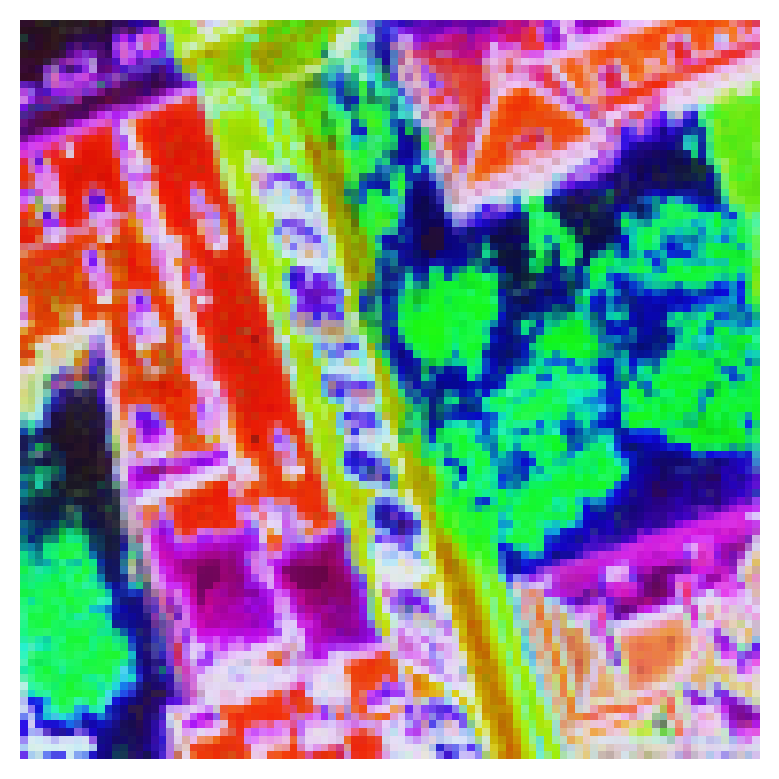

In [12]:
h_patches = image_resized.shape[1] // 16
w_patches = image_resized.shape[2] // 16
projected_image = torch.from_numpy(pca.transform(x.numpy())).view(h_patches, w_patches, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)
# enjoy
plt.figure(dpi=200)
plt.imshow(projected_image.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [ ]:
# 1. extract PCA for all image chips within the MSU site maxar data
# 2. visualize those in QGIS with the point data from MSU
# 3. alignment step regardless we need the CHM for that
#


# output

# lat, lon, species, canopy height, dense embedding vector of the tree

# John to point to the s3 locations of the input files 